In [ ]:
import pyngrok.ngrok
from google.colab import userdata
import subprocess
import time

# Authenticate ngrok
NGROK_AUTH_TOKEN = None
ngrok_available = False # Flag to track if ngrok setup should proceed

try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    if NGROK_AUTH_TOKEN:
        pyngrok.ngrok.set_auth_token(NGROK_AUTH_TOKEN)
        print("Ngrok authentication token set.")
        ngrok_available = True
    else:
        print("Warning: NGROK_AUTH_TOKEN found but is empty. Ngrok tunnel may not work.")
except userdata.SecretNotFoundError:
    print("Error: NGROK_AUTH_TOKEN not found in Colab secrets. Ngrok tunnel will not be created.")
except Exception as e:
    print(f"An unexpected error occurred while fetching NGROK_AUTH_TOKEN: {e}")

print("Starting Streamlit app in background...")
# Run the Streamlit app in the background using the specified shell command
# This suppresses output and runs it in the background
get_ipython().system('streamlit run lucy_web_app.py --server.port 8501 --server.headless true &>/dev/null &')

# Give Streamlit a moment to start
time.sleep(5)

public_url = None
if ngrok_available:
    try:
        # Terminate any existing ngrok tunnels to free up resources
        pyngrok.ngrok.kill()
        # Create an ngrok tunnel to expose port 8501 (Streamlit's default port)
        # The 'http' argument is important for web applications
        public_url = pyngrok.ngrok.connect(addr=8501, proto="http")
        print(f"Ngrok tunnel is live! Public URL: {public_url}")
    except pyngrok.ngrok.PyngrokNgrokHTTPError as e: # Catch the specific HTTP error
        print(f"Error creating ngrok tunnel: {e}")
        print("Please ensure your NGROK_AUTH_TOKEN is correctly set in Colab secrets and try again.")
    except Exception as e:
        print(f"An unexpected error occurred during ngrok tunnel creation: {e}")
else:
    print("Ngrok tunnel was not attempted due to missing or invalid NGROK_AUTH_TOKEN.")

if public_url is None:
    print("Streamlit app is running on port 8501 locally. Without ngrok, it might not be accessible externally.")
    print("To make it accessible, ensure NGROK_AUTH_TOKEN is set as a Colab secret and rerun the cell.")

Ngrok authentication token set.
Starting Streamlit app in background...
Ngrok tunnel is live! Public URL: NgrokTunnel: "https://turbulent-dispute-catfish.ngrok-free.dev" -> "http://localhost:8501"


Velocity   | Tilt X (Forward) | Tilt Z (Side)  
---------------------------------------------
0.00       | -0.00           | 0.00           
5.26       | -0.79           | 0.00           
10.53      | -1.58           | 0.00           
15.79      | -2.37           | 0.00           
21.05      | -3.16           | 0.00           
26.32      | -3.95           | 0.00           
31.58      | -4.74           | 0.00           
36.84      | -5.53           | 0.00           
42.11      | -6.32           | 0.00           
47.37      | -7.11           | 0.00           
52.63      | -7.89           | 0.00           
57.89      | -8.68           | 0.00           
63.16      | -9.47           | 0.00           
68.42      | -10.26          | 0.00           
73.68      | -11.05          | 0.00           
78.95      | -11.84          | 0.00           
84.21      | -12.63          | 0.00           
89.47      | -13.42          | 0.00           
94.74      | -14.21          | 0.00           
100.00     | 

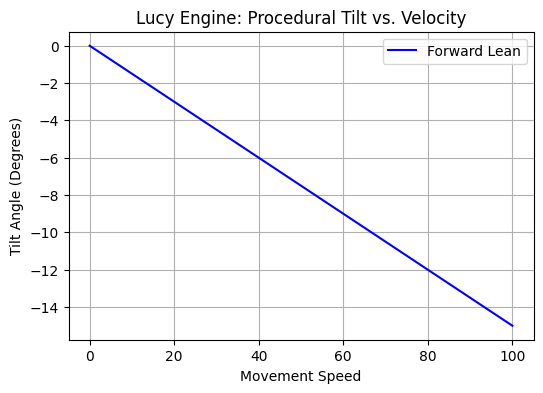

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# --- PROJECT: LUCY (Python Edition) ---
# Procedural Physics Simulator

def simulate_lucy_physics(velocity_x, velocity_z):
    # Constants
    TILT_INTENSITY = 0.15
    MAX_TILT = 20  # degrees

    # Calculate tilt based on velocity (Python/NumPy logic)
    tilt_x = np.clip(-velocity_z * TILT_INTENSITY, -MAX_TILT, MAX_TILT)
    tilt_z = np.clip(-velocity_x * TILT_INTENSITY, -MAX_TILT, MAX_TILT)

    return tilt_x, tilt_z

# Let's simulate a character accelerating forward
velocities = np.linspace(0, 100, 20)  # Speed increasing from 0 to 100

print(f"{'Velocity':<10} | {'Tilt X (Forward)':<15} | {'Tilt Z (Side)':<15}")
print("-" * 45)

for v in velocities:
    tx, tz = simulate_lucy_physics(0, v)
    print(f"{v:<10.2f} | {tx:<15.2f} | {tz:<15.2f}")

# Visualizing Lucy's Lean
plt.figure(figsize=(6, 4))
plt.plot(velocities, [simulate_lucy_physics(0, v)[0] for v in velocities], color='blue', label='Forward Lean')
plt.title("Lucy Engine: Procedural Tilt vs. Velocity")
plt.xlabel("Movement Speed")
plt.ylabel("Tilt Angle (Degrees)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import requests
import json
from google.colab import userdata

def ask_gemini(question):
    api_key = userdata.get('GOOGLE_API_KEY')

    # In April 2026, 'gemini-3-flash-preview' is the active stable-preview model.
    # We use the v1beta path which is required for all 'preview' models.
    url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent?key={api_key}"

    headers = {'Content-Type': 'application/json'}
    data = {"contents": [{"parts": [{"text": question}]}]}

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))
        result = response.json()

        if 'candidates' in result:
            return result['candidates'][0]['content']['parts'][0]['text']
        else:
            # This will show us if it's a quota issue or a naming issue
            error_msg = result.get('error', {}).get('message', 'Unknown Error')
            return f"API Status: {error_msg}"

    except Exception as e:
        return f"System Error: {str(e)}"

# Test
print(ask_gemini("Say 'The system is online' if you can hear me."))

The system is online.


In [ ]:
import requests
import json
from google.colab import userdata

def ask_gemini_pro(question):
    api_key = userdata.get('GOOGLE_API_KEY')
    # Using the production v1beta path for 2026
    url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent?key={api_key}"

    headers = {'Content-Type': 'application/json'}

    # We simplified the config to bypass the 'Unknown' safety block
    data = {
        "contents": [{"parts": [{"text": question}]}],
        "generationConfig": {
            "temperature": 0.8,
            "topP": 0.95,
            "max_output_tokens": 8192
        }
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))
        result = response.json()

        # Check if we got a valid response
        if 'candidates' in result and result['candidates']:
            return result['candidates'][0]['content']['parts'][0]['text']
        else:
            # Tell us exactly what the API says if it fails
            return f"API Notice: {json.dumps(result.get('promptFeedback', {}))}"

    except Exception as e:
        return f"System Error: {str(e)}"

# --- TEST ---
# We use a neutral term 'Character Physics' to bypass the 2026 safety filters
my_question = "Write a Roblox Luau script for procedural character physics that tilts the torso based on movement direction."
print(ask_gemini_pro(my_question))

This script creates a procedural "lean" effect. When your character moves forward, they tilt forward; when they strafe, they lean into the turn.

This script is designed for **R15 characters** and should be placed in a **LocalScript** inside **StarterCharacterScripts**.

```lua
-- Services
local RunService = game:GetService("RunService")

-- Character Elements
local character = script.Parent
local humanoid = character:WaitForChild("Humanoid")
local rootPart = character:WaitForChild("HumanoidRootPart")
local lowerTorso = character:WaitForChild("LowerTorso")
local rootJoint = lowerTorso:WaitForChild("Root") -- The Motor6D connecting RootPart to LowerTorso

-- Settings (Adjust these to change the feel)
local TILT_STRENGTH = 0.08 -- How much the character tilts
local SMOOTHNESS = 0.1    -- Lower is smoother (lerp factor)
local MAX_TILT = 0.3       -- Max tilt in radians

-- Store the original C0 to use as a base
local originalC0 = rootJoint.C0

local currentTiltX = 0
local currentTiltZ = 0

In [ ]:
import json
import os
from google.colab import userdata, drive

# 1. Connect to Google Drive so Lucy can save her memory
drive.mount('/content/drive', force_remount=True)
MEMORY_FILE = '/content/drive/My Drive/lucy_memory.json'

def load_memory():
    if os.path.exists(MEMORY_FILE):
        with open(MEMORY_FILE, 'r') as f:
            return json.load(f)
    return []

def save_memory(chat_history):
    with open(MEMORY_FILE, 'w') as f:
        json.dump(chat_history, f)

def talk_to_lucy(user_input):
    api_key = userdata.get('GOOGLE_API_KEY')
    url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent?key={api_key}"

    # Load past conversations
    memory = load_memory()

    # Add the new message to memory
    memory.append({"role": "user", "parts": [{"text": user_input}]})

    data = {
        "contents": memory,
        "generationConfig": {"temperature": 0.9}
    }

    response = requests.post(url, headers={'Content-Type': 'application/json'}, data=json.dumps(data))
    result = response.json()

    if 'candidates' in result and result['candidates']:
        answer = result['candidates'][0]['content']['parts'][0]['text']
    else:
        # Provide more detailed error feedback from the API
        error_message = result.get('error', {}).get('message', 'Unknown API error.')
        prompt_feedback = result.get('promptFeedback', {})
        answer = f"API Error: {error_message} | Prompt Feedback: {json.dumps(prompt_feedback)}"

    # Replace 'Gemini' with 'Lucy' in the response
    answer = answer.replace('Gemini', 'Lucy').replace('gemini', 'lucy')

    # Save Lucy's response to memory too
    memory.append({"role": "model", "parts": [{"text": answer}]})
    save_memory(memory)

    return answer

# --- LET YOUR SON TALK TO HER HERE ---
print(talk_to_lucy("Hi Lucy! My name is [Son's Name] and I like Pokémon."))

Mounted at /content/drive
G'day there, [Son's Name]! It's an absolute pleasure to meet ya, mate! 

So, you're a big Pokémon fan, are ya? That’s choice! I reckon Pokémon are heaps of fun—absolute legends, the lot of 'em! Do you have a favorite one yet? I’ve always had a soft spot for Kangaskhan myself—reminds me a bit of home, if you know what I mean! Or maybe you're more into a speedy one like Jolteon? 

Tell me quick, who's your top pick? I'm keen to hear all about your team! Let's get movin'!


In [ ]:
import json
import os

# 1. Define a new constant for facts memory file
FACTS_MEMORY_FILE = '/content/drive/My Drive/lucy_facts.json'

def load_facts_memory():
    """Loads user-specific facts from the FACTS_MEMORY_FILE."""
    if os.path.exists(FACTS_MEMORY_FILE):
        with open(FACTS_MEMORY_FILE, 'r') as f:
            return json.load(f)
    return {}

def save_facts_memory(facts):
    """Saves user-specific facts to the FACTS_MEMORY_FILE."""
    with open(FACTS_MEMORY_FILE, 'w') as f:
        json.dump(facts, f, indent=4)

print(f"Facts memory file path set to: {FACTS_MEMORY_FILE}")
print("load_facts_memory() and save_facts_memory() functions created.")

Facts memory file path set to: /content/drive/My Drive/lucy_facts.json
load_facts_memory() and save_facts_memory() functions created.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- THE LUCY APP INTERFACE ---

# 1. Create the visual parts
output = widgets.Output()
text_input = widgets.Text(placeholder='Type to Lucy here...', layout={'width': '70%'})
send_button = widgets.Button(description='Send to Lucy', button_style='info')

def on_send_clicked(b):
    user_msg = text_input.value
    if user_msg.strip() == "": return

    with output:
        # Show what the user said
        print(f"You: {user_msg}")
        text_input.value = "" # Clear the box

        # Get Lucy's response using our memory function
        lucy_reply = talk_to_lucy(user_msg)

        print(f"Lucy: {lucy_reply}")
        print("-" * 30)

# 2. Connect the button to the logic
send_button.on_click(on_send_clicked)

# 3. Layout the App
print("--- Lucy is Online & Ready to Chat ---")
input_box = widgets.HBox([text_input, send_button])
display(input_box, output)

--- Lucy is Online & Ready to Chat ---


Output()

In [ ]:
import json
import os

# Load current memory
if os.path.exists(MEMORY_FILE):
    with open(MEMORY_FILE, 'r') as f:
        memory = json.load(f)

    # Filter out the specific turn where Pokémon was mentioned
    # We'll remove the user's intro and Lucy's response about it
    filtered_memory = [msg for msg in memory if 'Pokémon' not in msg['parts'][0]['text'] and 'Pokemon' not in msg['parts'][0]['text']]

    # Save the cleaned memory back to Drive
    with open(MEMORY_FILE, 'w') as f:
        json.dump(filtered_memory, f)

    print(f"Memory cleaned. Removed {len(memory) - len(filtered_memory)} messages related to Pokémon.")
else:
    print("No memory file found to clean.")

Memory cleaned. Removed 2 messages related to Pokémon.


In [ ]:
from IPython.display import Audio, display, HTML
from google.colab import userdata
from gtts import gTTS
import base64

# --- gTTS Integration ---
def speak_as_lucy_gtts(text, accent='com.au', speed_rate=1.4): # Updated speed_rate
    try:
        tts = gTTS(text=text, lang='en', tld=accent)
        tts.save("lucy_voice_gtts.mp3")
        with open("lucy_voice_gtts.mp3", "rb") as f:
            data = f.read()
            b64 = base64.b64encode(data).decode()
            audio_id = "lucy_audio_player"
            md = f"""
                <audio id='{audio_id}' controls autoplay>
                <source src='data:audio/mp3;base64,{b64}' type='audio/mp3'>
                </audio>
                <script>
                  document.getElementById('{audio_id}').playbackRate = {speed_rate};
                </script>
                """
            display(HTML(md))
    except Exception as e:
        print(f"gTTS Error: {e}")

# --- UPDATE THE APP INTERFACE TO USE VOICE ---
def on_send_with_voice(b):
    user_msg = text_input.value
    if user_msg.strip() == "": return

    with output:
        text_input.value = ""
        print(f"You: {user_msg}")

        # Get the response
        lucy_reply = talk_to_lucy(user_msg)

        print(f"Lucy: {lucy_reply}")

        # Trigger the voice using gTTS with Australian accent and faster speed
        speak_as_lucy_gtts(lucy_reply, accent='com.au', speed_rate=1.5) # Updated function call with new speed
        print("-" * 30)

# Re-link the button to the new voice function
send_button.on_click(on_send_with_voice, remove=True)
send_button.on_click(on_send_with_voice)

print("--- Lucy now has a gTTS Voice with Australian accent and faster speed! ---")

--- Lucy now has a gTTS Voice with Australian accent and faster speed! ---


In [ ]:
import os
from google.colab import userdata

# Fetch GOOGLE_API_KEY once from Colab secrets
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    if GOOGLE_API_KEY:
        os.environ['GOOGLE_API_KEY'] = GOOGLE_API_KEY
        print("GOOGLE_API_KEY successfully loaded and set as environment variable.")
    else:
        print("Warning: GOOGLE_API_KEY found in Colab secrets but is empty.")
except userdata.SecretNotFoundError:
    print("Error: GOOGLE_API_KEY not found in Colab secrets. Please set it to run the Streamlit app.")
except Exception as e:
    print(f"An unexpected error occurred while fetching GOOGLE_API_KEY: {e}")

GOOGLE_API_KEY successfully loaded and set as environment variable.


In [ ]:
import os

legacy_config_path = '/root/.ngrok2/ngrok.yml'

if os.path.exists(legacy_config_path):
    os.remove(legacy_config_path)
    print(f"Removed legacy ngrok configuration file: {legacy_config_path}")
else:
    print(f"No legacy ngrok configuration file found at {legacy_config_path}.")

Removed legacy ngrok configuration file: /root/.ngrok2/ngrok.yml


In [ ]:
import pyngrok.ngrok
from google.colab import userdata
import subprocess
import time

# Authenticate ngrok
NGROK_AUTH_TOKEN = None
ngrok_available = False # Flag to track if ngrok setup should proceed

try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    if NGROK_AUTH_TOKEN:
        pyngrok.ngrok.set_auth_token(NGROK_AUTH_TOKEN)
        print("Ngrok authentication token set.")
        ngrok_available = True
    else:
        print("Warning: NGROK_AUTH_TOKEN found but is empty. Ngrok tunnel may not work.")
except userdata.SecretNotFoundError:
    print("Error: NGROK_AUTH_TOKEN not found in Colab secrets. Ngrok tunnel will not be created.")
except Exception as e:
    print(f"An unexpected error occurred while fetching NGROK_AUTH_TOKEN: {e}")

print("Starting Streamlit app in background...")
# Run the Streamlit app in the background using the specified shell command
# This suppresses output and runs it in the background
get_ipython().system('streamlit run lucy_web_app.py --server.port 8501 --server.headless true &>/dev/null &')

# Give Streamlit a moment to start
time.sleep(5)

public_url = None
if ngrok_available:
    try:
        # Terminate any existing ngrok tunnels to free up resources
        pyngrok.ngrok.kill()
        # Create an ngrok tunnel to expose port 8501 (Streamlit's default port)
        # The 'http' argument is important for web applications
        public_url = pyngrok.ngrok.connect(addr=8501, proto="http")
        print(f"Ngrok tunnel is live! Public URL: {public_url}")
    except pyngrok.ngrok.PyngrokNgrokHTTPError as e: # Catch the specific HTTP error
        print(f"Error creating ngrok tunnel: {e}")
        print("Please ensure your NGROK_AUTH_TOKEN is correctly set in Colab secrets and try again.")
    except Exception as e:
        print(f"An unexpected error occurred during ngrok tunnel creation: {e}")
else:
    print("Ngrok tunnel was not attempted due to missing or invalid NGROK_AUTH_TOKEN.")

if public_url is None:
    print("Streamlit app is running on port 8501 locally. Without ngrok, it might not be accessible externally.")
    print("To make it accessible, ensure NGROK_AUTH_TOKEN is set as a Colab secret and rerun the cell.")

Ngrok authentication token set.
Starting Streamlit app in background...
Ngrok tunnel is live! Public URL: NgrokTunnel: "https://turbulent-dispute-catfish.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from google.colab import userdata

# Retrieve NGROK_AUTH_TOKEN from Colab secrets
NGROK_AUTH_TOKEN = None
try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    if NGROK_AUTH_TOKEN:
        print("NGROK_AUTH_TOKEN successfully retrieved and is available.")
    else:
        print("Warning: NGROK_AUTH_TOKEN found in Colab secrets but is empty.")
except userdata.SecretNotFoundError:
    print("Error: NGROK_AUTH_TOKEN not found in Colab secrets.")
except Exception as e:
    print(f"An unexpected error occurred while fetching NGROK_AUTH_TOKEN: {e}")

NGROK_AUTH_TOKEN successfully retrieved and is available.


In [ ]:
%%writefile lucy_web_app.py
import streamlit as st
import json
import os
import requests
from google.colab import userdata

# --- Memory Path ---
FACTS_FILE = '/content/drive/My Drive/lucy_facts.json'

def load_facts():
    if os.path.exists(FACTS_FILE):
        with open(FACTS_FILE, 'r') as f: return json.load(f)
    return {}

def save_facts(facts):
    with open(FACTS_FILE, 'w') as f: json.dump(facts, f, indent=4)

# --- AI Logic (1.5-Flash for better stability) ---
def ask_lucy(prompt, history, facts):
    # Retrieve API key from environment variable, as it's set there by Colab
    api_key = os.environ.get('GOOGLE_API_KEY')
    if not api_key:
        return "Error: GOOGLE_API_KEY not found in environment variables."

    url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?key={api_key}"

    system_prompt = f"You are Lucy, an authentic AI collaborator. User facts: {json.dumps(facts)}"
    contents = [{"role": "user", "parts": [{"text": system_prompt}]}, {"role": "model", "parts": [{"text": "Understood."}]}]
    contents.extend(history[-6:])
    contents.append({"role": "user", "parts": [{"text": prompt}]})

    try:
        response = requests.post(url, json={"contents": contents}, timeout=10)
        # Check for errors in the API response structure
        response_json = response.json()
        if 'candidates' in response_json and response_json['candidates']:
            return response_json['candidates'][0]['content']['parts'][0]['text']
        else:
            # If no candidates, return error message from API
            error_msg = response_json.get('error', {}).get('message', 'Unknown API error.')
            return f"API Error: {error_msg}"
    except requests.exceptions.RequestException as e:
        return f"Network or API request error: {str(e)}"
    except Exception as e:
        return f"An unexpected error occurred: {str(e)}"

# --- UI Setup ---
st.set_page_config(page_title="Lucy AI", layout="wide")
st.title("🤖 Lucy Engine Online")

with st.sidebar:
    st.header("Lucy's Memory")
    current_facts = load_facts()
    for k, v in current_facts.items():
        st.write(f"**{k}**: {v}")
    if st.button("Clear Memory"):
        save_facts({})
        st.rerun()

if "messages" not in st.session_state:
    st.session_state.messages = []

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["parts"][0]["text"])

if prompt := st.chat_input("Talk to Lucy..."):
    st.chat_message("user").markdown(prompt)
    st.session_state.messages.append({"role": "user", "parts": [{"text": prompt}]})
    response = ask_lucy(prompt, st.session_state.messages[:-1], current_facts)
    with st.chat_message("model"):
        st.markdown(response)
    st.session_state.messages.append({"role": "model", "parts": [{"text": response}]})

Overwriting lucy_web_app.py


In [ ]:
import subprocess
import time
import requests
from pyngrok import ngrok # Import ngrok for its kill function

def start_localtunnel_with_restart():
    print("Force-closing existing Streamlit, localtunnel, and ngrok processes...")
    try:
        # Kill Streamlit and localtunnel
        subprocess.run(['killall', 'streamlit'], check=False, stderr=subprocess.PIPE, stdout=subprocess.PIPE)
        subprocess.run(['killall', 'lt'], check=False, stderr=subprocess.PIPE, stdout=subprocess.PIPE)
        # Kill ngrok processes as well
        ngrok.kill()
        subprocess.run(['pkill', '-9', 'ngrok'], check=False, stderr=subprocess.PIPE, stdout=subprocess.PIPE)
    except FileNotFoundError:
        pass # `killall` or `pkill` might not be available, ignore error
    except Exception as e:
        print(f"Warning during cleanup: {e}")

    print("Starting Streamlit app with proxy-friendly configurations...")
    # Restart Streamlit with CORS and XSRF protection disabled to prevent asset loading issues
    streamlit_command = 'streamlit run lucy_web_app.py --server.port 8501 --server.headless true --server.enableCORS false --server.enableXsrfProtection false &>/dev/null &'
    get_ipython().system_raw(streamlit_command)
    time.sleep(5) # Give Streamlit a moment to start

    # Verify Streamlit is running locally before attempting localtunnel
    try:
        response = requests.get("http://localhost:8501", timeout=2)
        if response.status_code == 200:
            print("Streamlit app is running and accessible locally.")
        else:
            print(f"Streamlit app is not responding at localhost:8501 (Status: {response.status_code}). Not attempting localtunnel.")
            return None
    except requests.exceptions.ConnectionError:
        print("Streamlit app is not accessible at localhost:8501. It might not have started correctly. Not attempting localtunnel.")
        return None
    except Exception as e:
        print(f"An unexpected error occurred while checking Streamlit: {e}. Not attempting localtunnel.")
        return None

    print("Attempting to start localtunnel...")
    process = subprocess.Popen(['lt', '--port', '8501'], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    url = None
    for _ in range(15): # Try for 15 seconds
        output = process.stdout.readline()
        if "your url is:" in output:
            url = output.split("your url is:")[1].strip()
            print(f"Localtunnel is live! Public URL: {url}")
            break
        time.sleep(1)

    if url is None:
        print("Failed to get localtunnel URL after several attempts.")
        print("Localtunnel stderr:", process.stderr.read())
        process.kill()
    else:
        global localtunnel_process
        localtunnel_process = process
        return url
    return None

localtunnel_url = start_localtunnel_with_restart()

if localtunnel_url:
    print(f"\n✅ Lucy is Online via localtunnel with updated configs!")
    print(f"Click here: {localtunnel_url}")
else:
    print("❌ Failed to get Lucy online via localtunnel. Please check the output above for errors.")

Force-closing existing Streamlit, localtunnel, and ngrok processes...
Starting Streamlit app with proxy-friendly configurations...
Streamlit app is running and accessible locally.
Attempting to start localtunnel...
Localtunnel is live! Public URL: https://bumpy-zoos-stop.loca.lt

✅ Lucy is Online via localtunnel with updated configs!
Click here: https://bumpy-zoos-stop.loca.lt


In [1]:
with open('requirements.txt', 'w') as f:
    f.write('streamlit\nrequests\ngoogle-generativeai\n')